## 1 Import des bibliotheques nécessaires


In [18]:
import numpy as np 
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## 2 Presentation de la problématique et importation des données

### 2.1 Présentation de la problématique

Le jeu de données "California Housing" contient des informations sur les logements en Californie, aux États-Unis, ainsi que leur valeur. L'objectif de ce jeu de projet prédire la valeur des logements en fonction de leurs caractéristiques.

Le fichier de données peut être téléchargé à partir de la page Kaggle suivante : California Housing

Les variables présentes dans le jeu de données sont les suivantes :

- **longitude :** Longitude de la localisation du logement
- **latitude :** Latitude de la localisation du logement
- **housing_median_age :** Âge médian des logements dans la région
- **total_rooms :** Nombre total de chambres dans la région
- **total_bedrooms :** Nombre total de chambres à coucher dans la région
- **population :** Population totale dans la région
- **households :** Nombre total de ménages dans la région
- **median_income :** Revenu médian des ménages dans la région
- **median_house_value :** Valeur médiane des maisons dans la région
- **ocean_proximity :** Proximité de la maison par rapport à l'océan (côte, île, etc.)

## 2.2 Importation et nettoyage des données

In [19]:
# verification du chemin d'acces
import os

chemin = os.getcwd()
print('Le chemin d\'acces est', chemin) 

Le chemin d'acces est C:\Users\User\Espace expérimental


In [39]:
# chargement de la base de données
import pandas as pd
data = pd.read_csv("housing.csv", sep=';', decimal=',')

In [40]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21.0,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52.0,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52.0,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52.0,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [41]:
# Information sur la base de données
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(5), int64(4), object(1)
memory usage: 1.6+ MB


In [32]:
# Erreur corrigé, cette cellule est importante si l'on a des caracteres parasites.

# Revoyons les variables longitude, latitude, housing_median_age et median_income qui doivent normalement etre numériques

# Identifions ls parasites
import pandas as pd
var_a_exclure = ["ocean_proximity"]

for col in data.select_dtypes(include='object').columns:
    if col not in var_a_exclure:
        parasites = data[col][
            ~data[col].astype(str)
                   .str.replace(',','.')
                   .str.match(r'^-?\d+(\.\d+)?$')
        ].unique()
        if len(parasites) > 0:
            print(f"👉 Valeurs non numériques dans la colonne '{col}': {parasites}")

# Aucun parasite detecter, on passe a la conversion de ces variables
var_a_exclure = ["ocean_proximity"]
for col in data.select_dtypes(include='object').columns:
    if col not in var_a_exclure:
        data[col] = pd.to_numeric(data[col], errors="coerce")
        


In [42]:
# Analyse des données manquantes 
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [43]:
# Description des données
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [44]:
# On suppose que les regions (les observations representes les observation) qui ont la variable total_bedrooms manquantes n'ont pas de chambre
# Remplacement des valeurs manquantes par 0 pour la variable 'total_bedrooms'
data['total_bedrooms'].fillna(0, inplace=True)
data.isnull().sum()

C:\Users\User\AppData\Local\Temp\ipykernel_34016\694984011.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['total_bedrooms'].fillna(0, inplace=True)


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## 3 Description des biens de la base de données

### 3.1 Description des variables numériques 

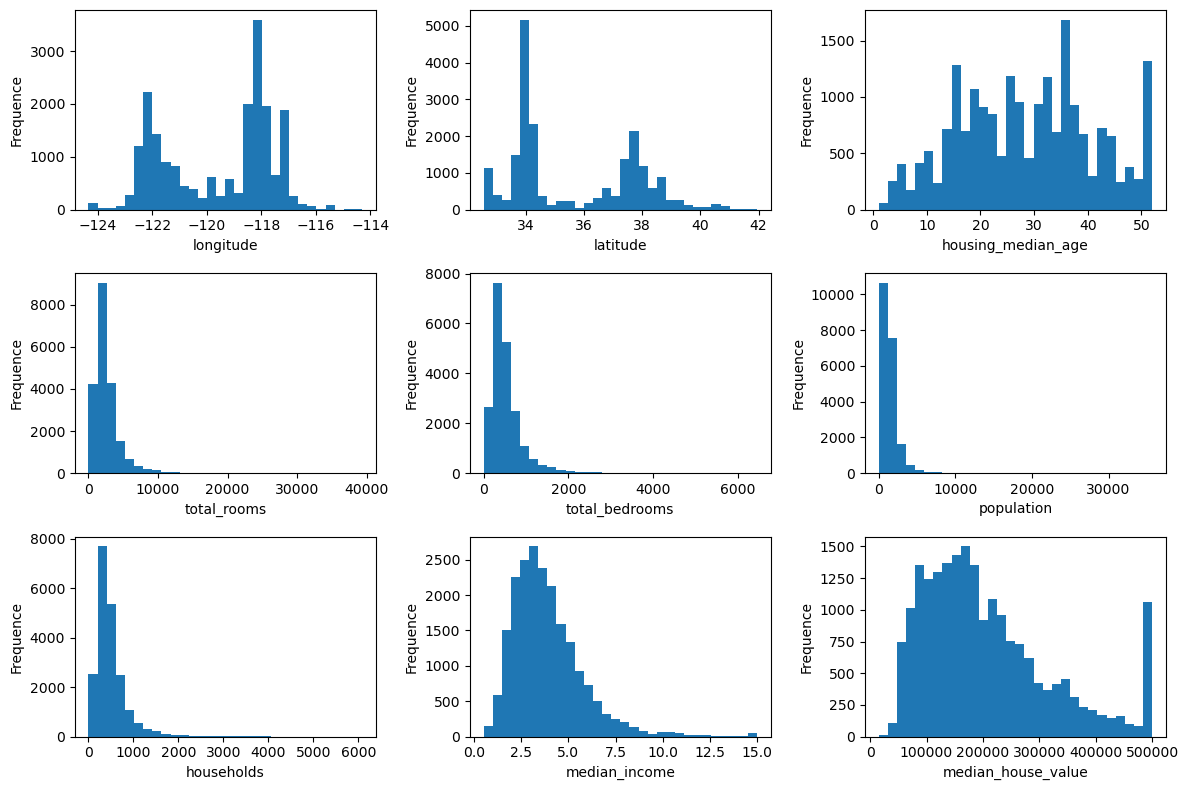

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Description univariée des variables numériques
# Selection des variables quantitatives
quant_vars = data.select_dtypes(include=np.number).columns

# Creation des subplots pour chaque variable quantitative sur une meme figure
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))
axs = axs.flatten()
for i, var in enumerate(quant_vars):
    axs[i].hist(data[var], bins=30)
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('Frequence')
plt.tight_layout()
plt.show()

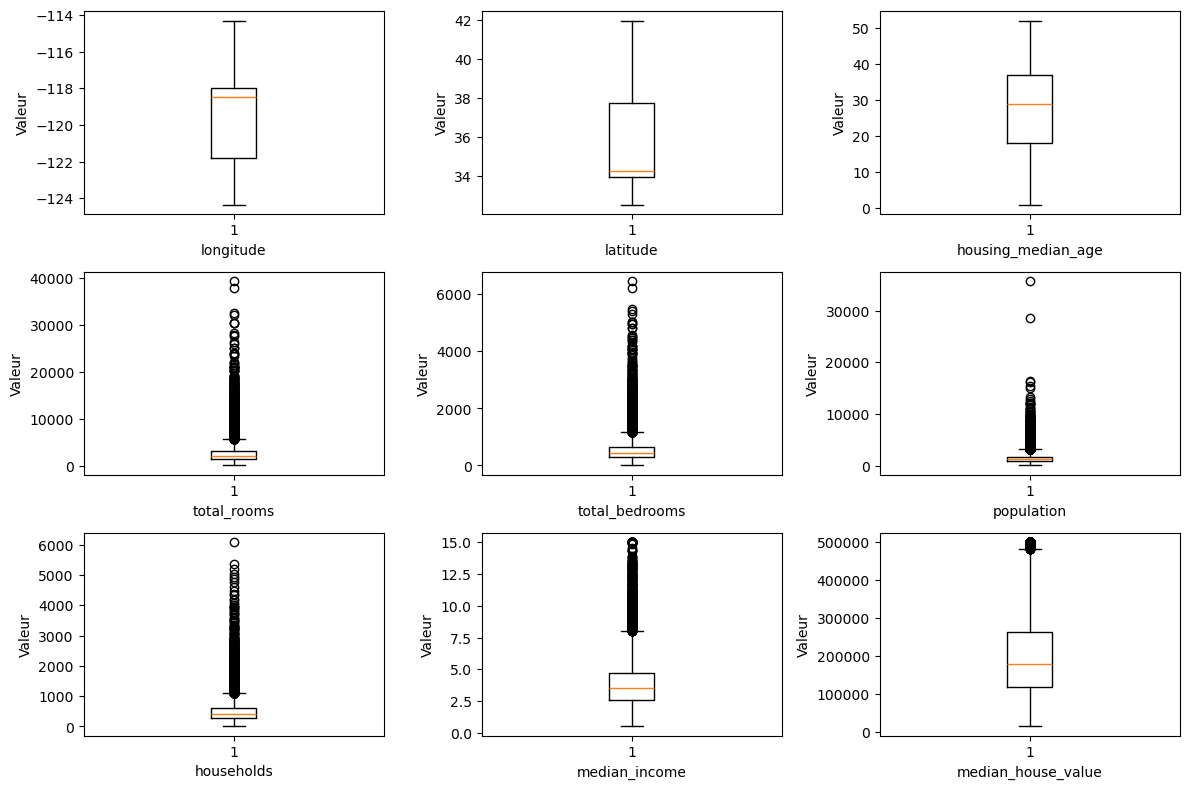

In [46]:
quant_vars = data.select_dtypes(include='number').columns
# Creation des subplots pour chaque variable quantitative sur une meme figure
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))
axs = axs.flatten()
for i, var in enumerate(quant_vars):
    axs[i].boxplot(data[var])
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('Valeur')
plt.tight_layout()
plt.show()

On va pas s'attarder ici sur les Outliers

### 3.2 Description de la variable catégorielle 'ocean_proximity'

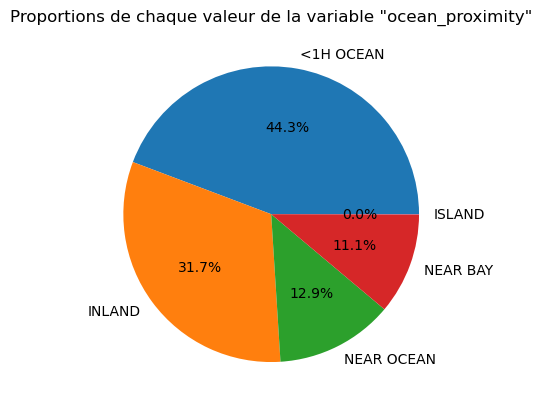

In [48]:
# Calcul des proportions pour chaque valeur de la variable catégorielle
prop_counts = data['ocean_proximity'].value_counts(normalize=True)

# Proportion du pie chart
plt.pie(prop_counts, labels=prop_counts.index, autopct='%1.1f%%')
plt.title('Proportions de chaque valeur de la variable "ocean_proximity"')
plt.show()

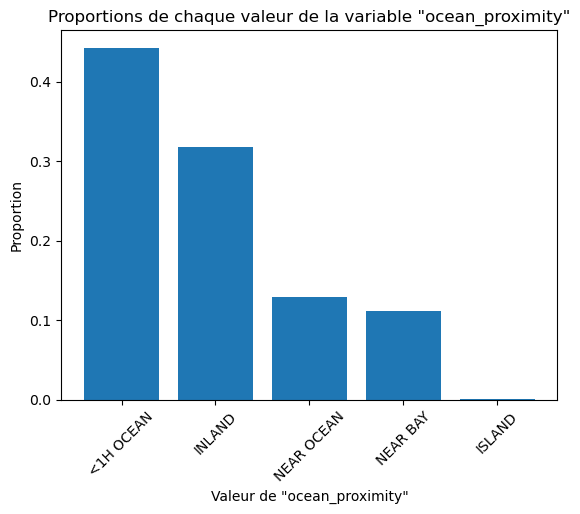

In [50]:
# Calcul des proportions pour chaque valeur de la variable catégorielle
prop_counts = data['ocean_proximity'].value_counts(normalize=True)

# Création du barplot
plt.bar(x=prop_counts.index, height=prop_counts)
plt.xticks(rotation=45)
plt.xlabel('Valeur de "ocean_proximity"')
plt.ylabel('Proportion')
plt.title('Proportions de chaque valeur de la variable "ocean_proximity"')
plt.show()

## 4 Analyses et sélection des variables pertinentes

### 4.1 Corrélation entre les variables numériques

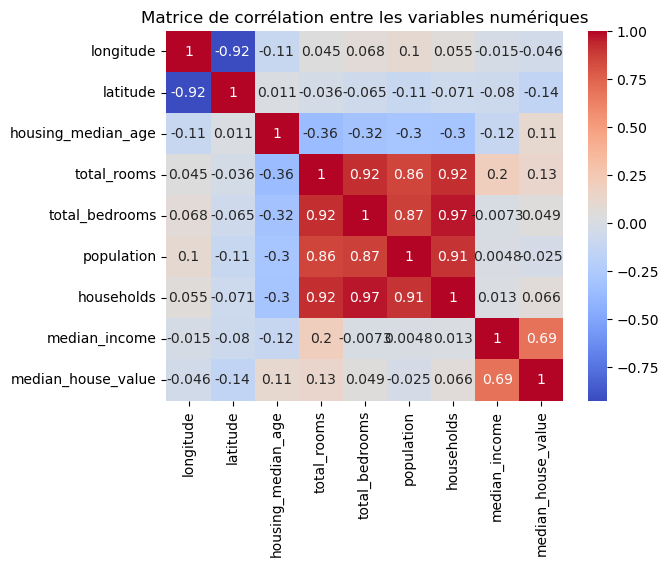

In [52]:
import seaborn as sns
# Correlation entre les variables numeriques 
corr_matrix = data.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation entre les variables numériques')
plt.show()

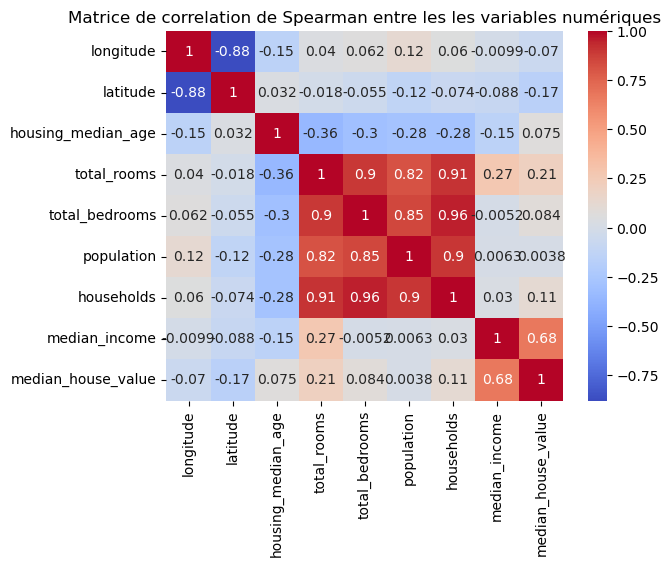

In [55]:
# Selection des variables numériques
num_vars = data.select_dtypes(include=np.number).columns
# Calcul de la matrice de correlation de Spearman
corr_matrix = data[num_vars].corr(method='spearman')

# Affichage de la matrice de la corrélation de Spearman
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de correlation de Spearman entre les les variables numériques')
plt.show()

## 4.2 Relation entre la variale cible 'median_house_value' et les variables numériques

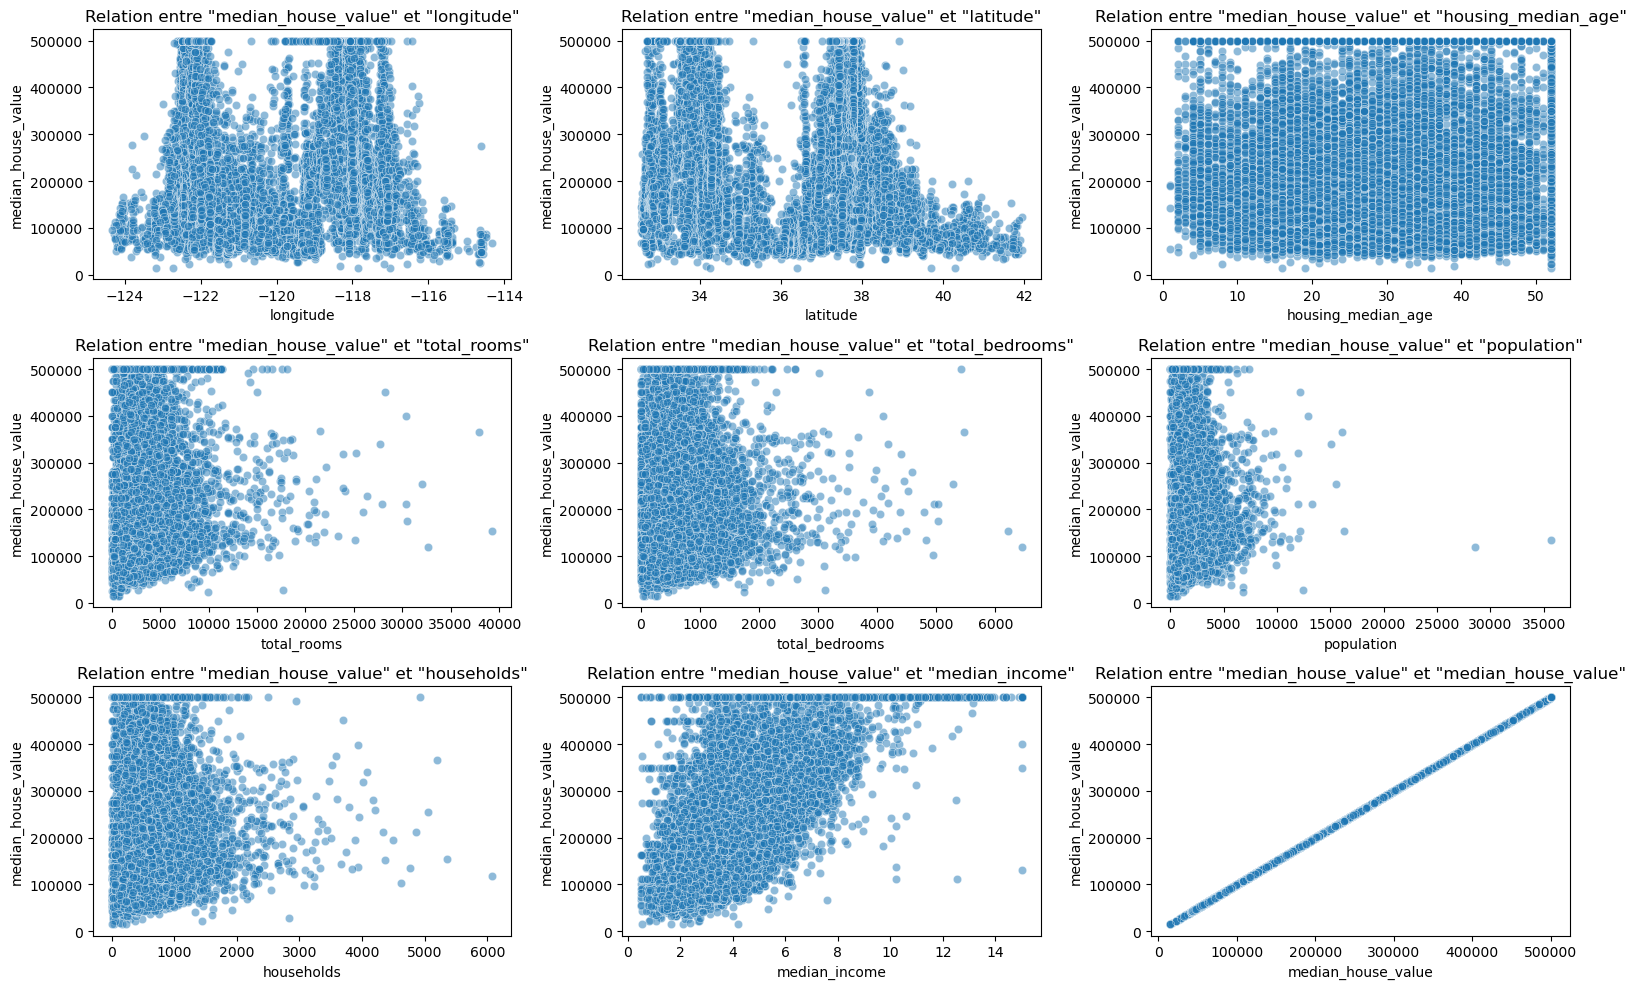

In [58]:
# Selection des variables numériques
num_vars = data.select_dtypes(include=np.number).columns

# Calcul de la taille de la matrice des subpots en fonction du nombre de variables numériques
n_cols = 3
n_rows = int(np.ceil(len(num_vars)/n_cols))

# Affichage des scatterplots  pour chaque variable numerique sur une meme figure avec des subplots
fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, 10))
axs =axs.flatten()

for i, var in enumerate(num_vars):
    sns.scatterplot(x=var, y='median_house_value', data=data, alpha=0.5, ax=axs[i])
    axs[i].set_title('Relation entre "median_house_value" et "{}"'.format(var))

# Ajout des titres et des étiquettes des axes
plt.tight_layout()
plt.show()

###  4.3 Relation entre la variable cible 'median_house_value' et la variable catégorielle 'ocean_proximity'

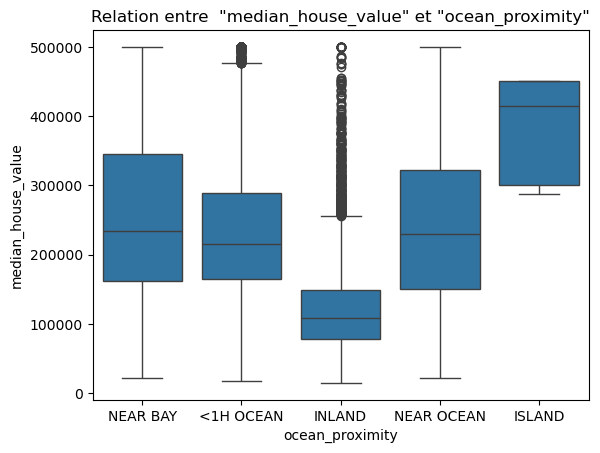

In [59]:
sns.boxplot(x='ocean_proximity', y='median_house_value', data=data)
plt.title('Relation entre  "median_house_value" et "ocean_proximity"')
plt.show()

## 4.4 Relation entre les variables numériques

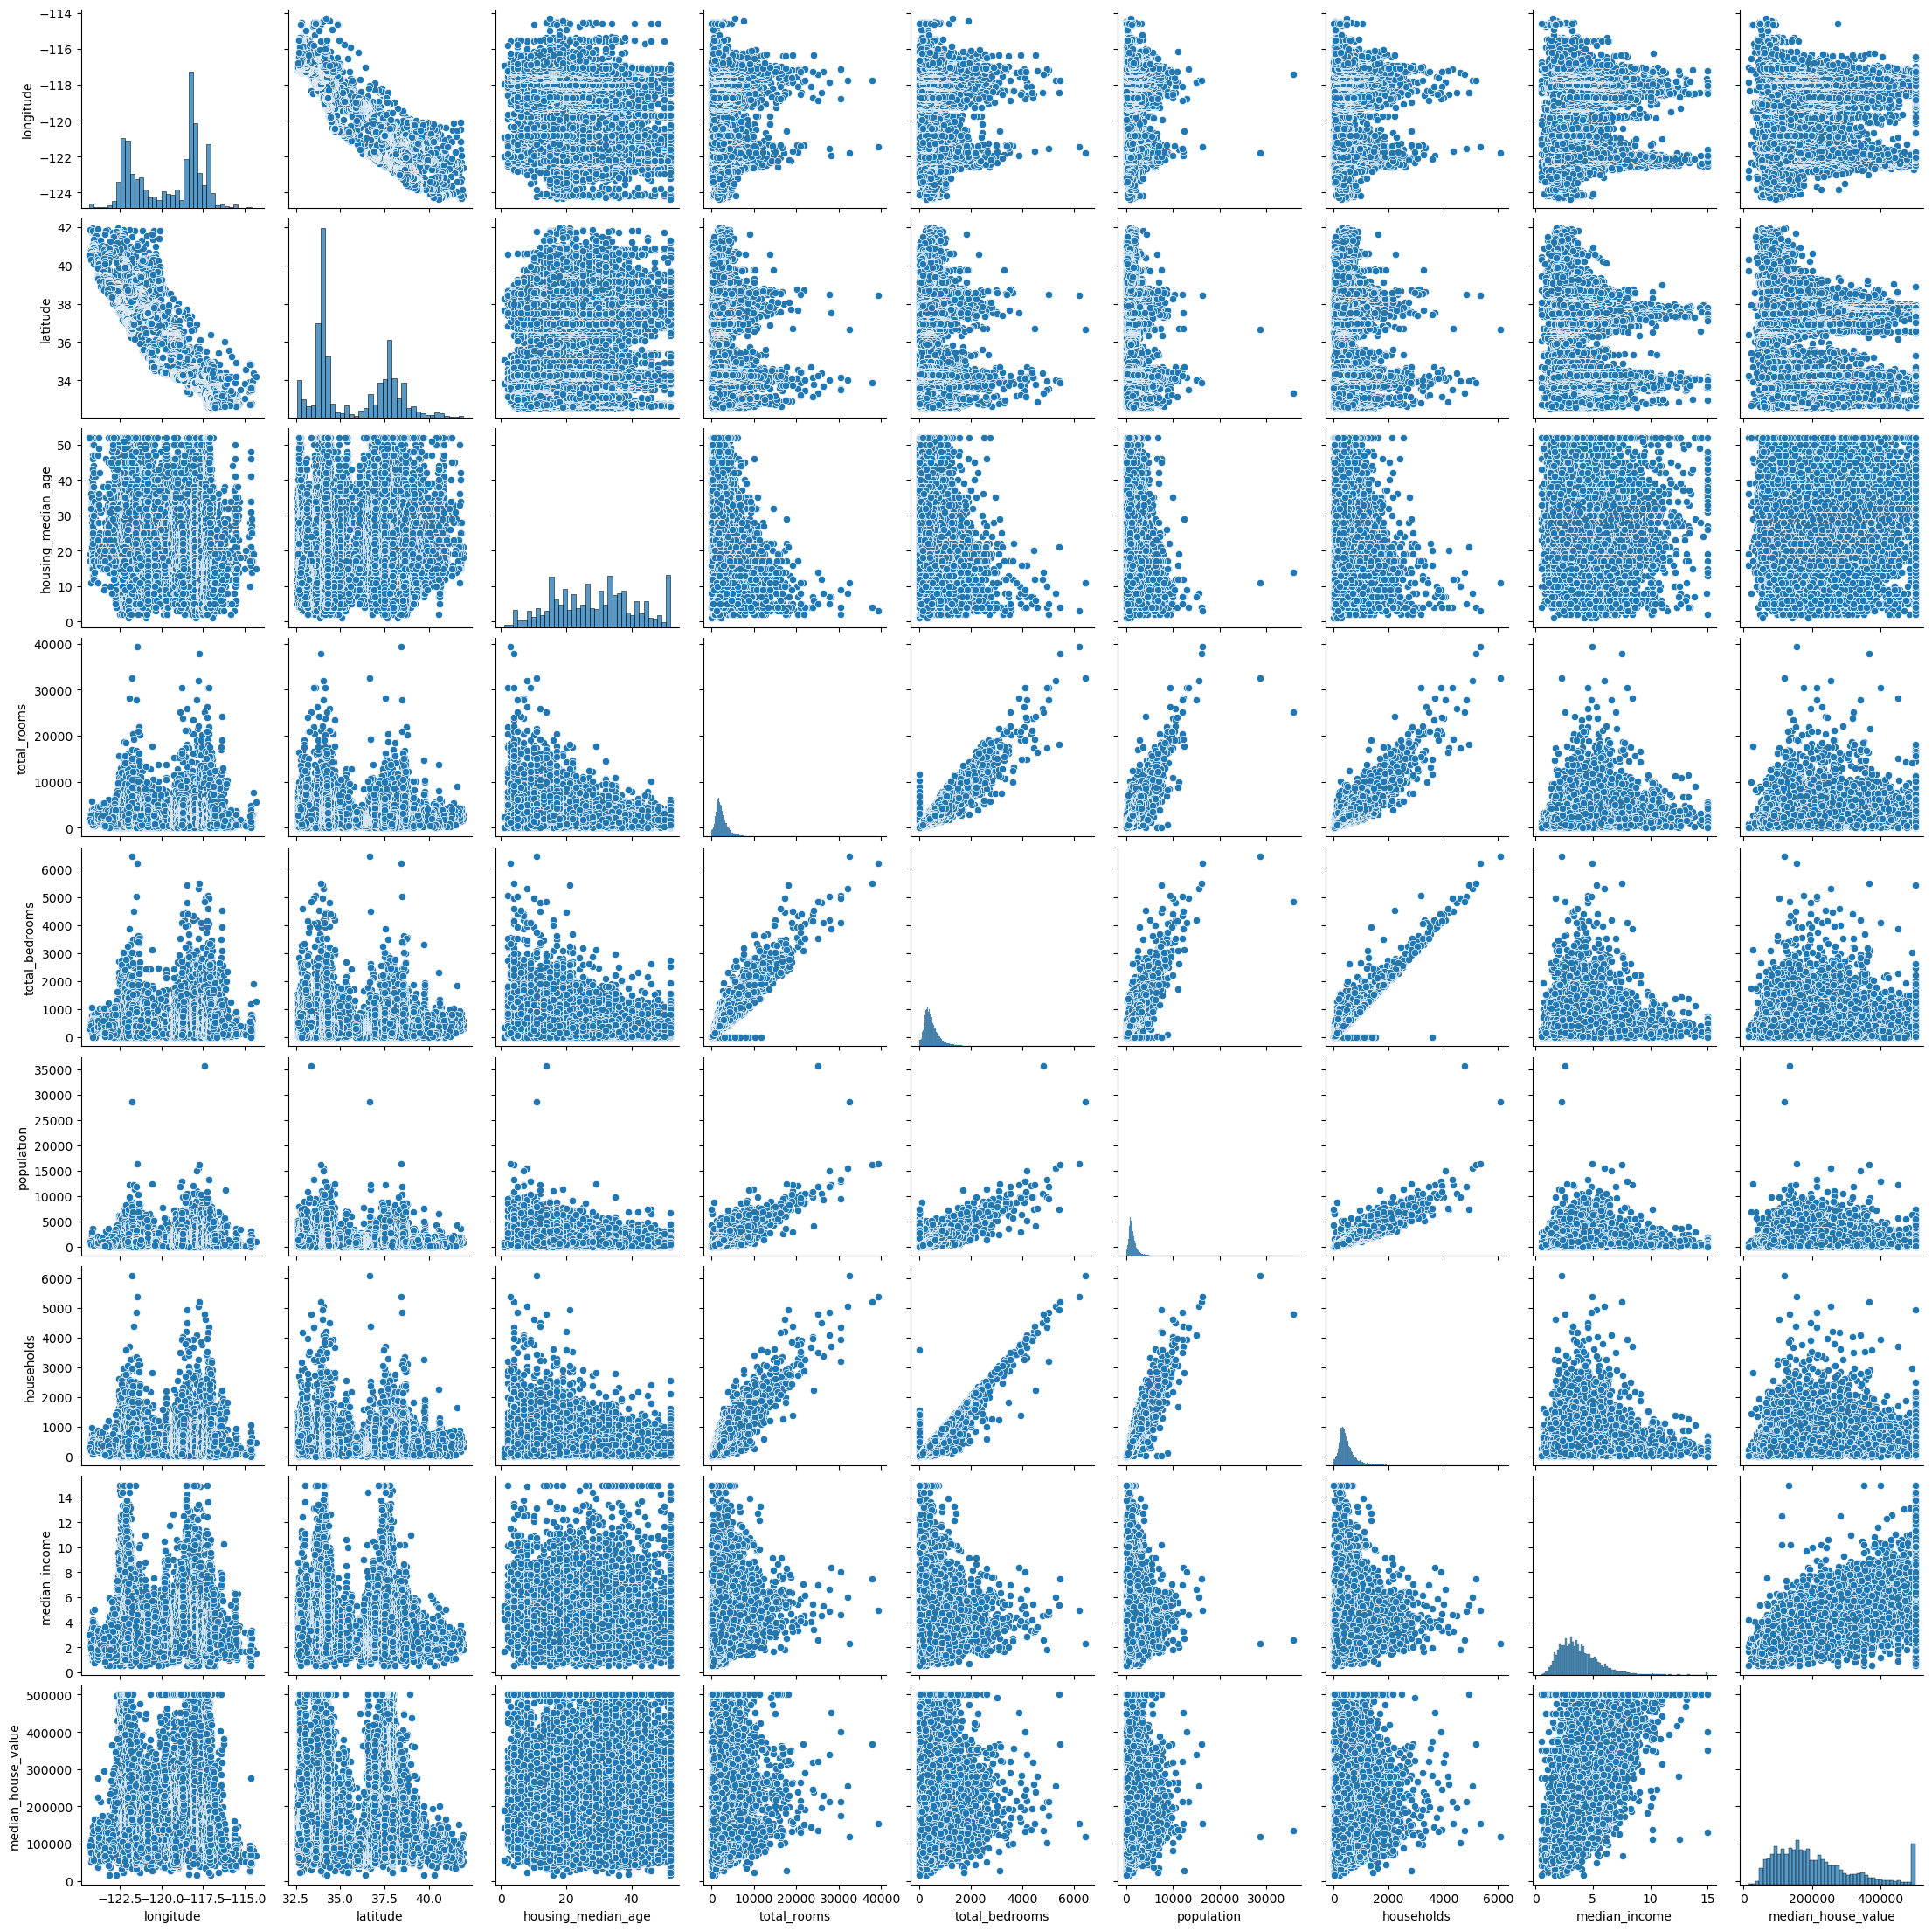

In [60]:
sns.pairplot(data[num_vars])
plt.show()

## 5 Modélisation du prix du bien immobilier

### 5.1 Variables

In [64]:
from sklearn.preprocessing import OneHotEncoder
# Selection des variabes categorielles 
cat_vars = ['ocean_proximity']

# Encodage binaire des variables catégorielles
encoder = OneHotEncoder(sparse_output=False)
cat_data = pd.DataFrame(encoder.fit_transform(data[cat_vars]))
cat_data.columns = encoder.get_feature_names_out(cat_vars)

# Remplacement des variables cateorielles par les variables encodées
data = pd.concat([data.drop(cat_vars, axis=1), cat_data], axis=1)

In [67]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880,129.0,322,126,8.3252,452600,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099,1106.0,2401,1138,8.3014,358500,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467,190.0,496,177,7.2574,352100,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274,235.0,558,219,5.6431,341300,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627,280.0,565,259,3.8462,342200,0.0,0.0,0.0,1.0,0.0


In [65]:
# Separation des données en variables explicatives et variable cible 
x = data.drop('median_house_value', axis=1)
y= data['median_house_value']

### 5.2 Diviser la base en train en test

In [68]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### 5.3 Arbre de regression non optimisé

In [69]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
tree = DecisionTreeRegressor(random_state=42)
tree.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

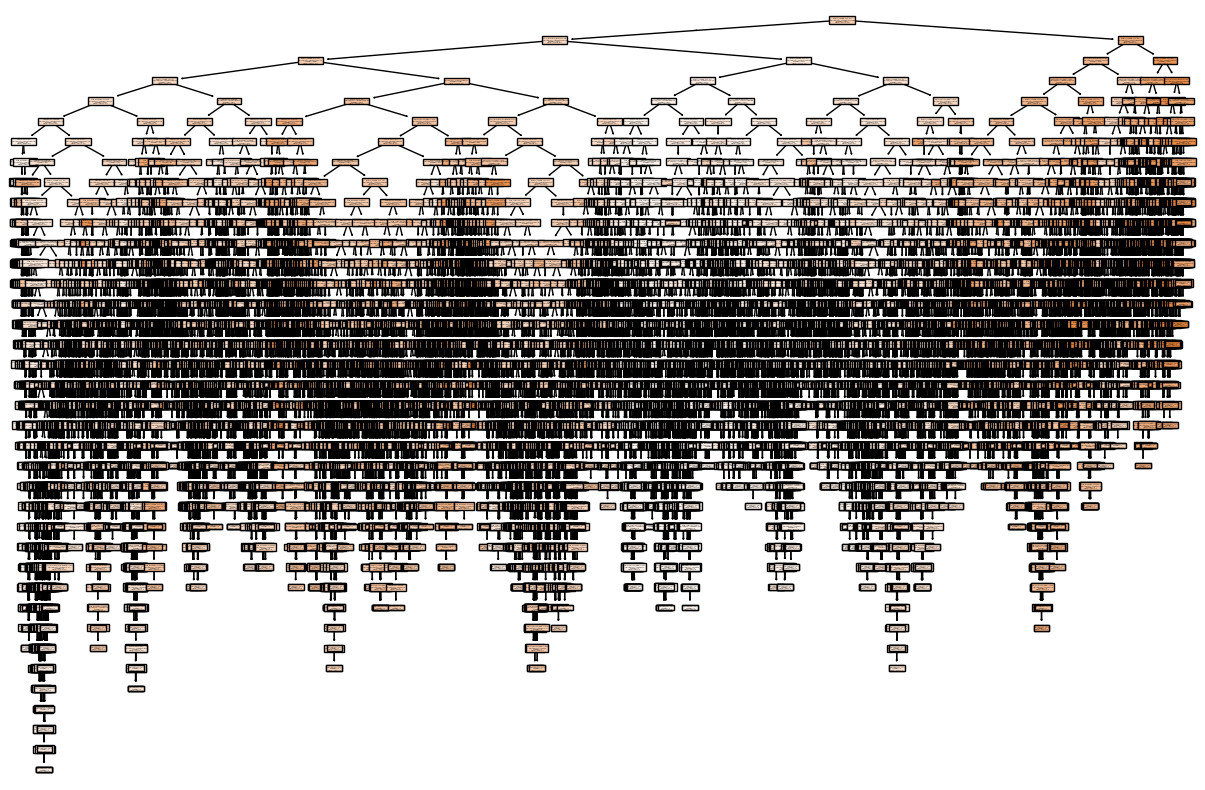

In [70]:
# Affichage de l'arbre
plt.figure(figsize=(15, 10))
plot_tree(tree, feature_names=x_train.columns, filled=True)
plt.show()

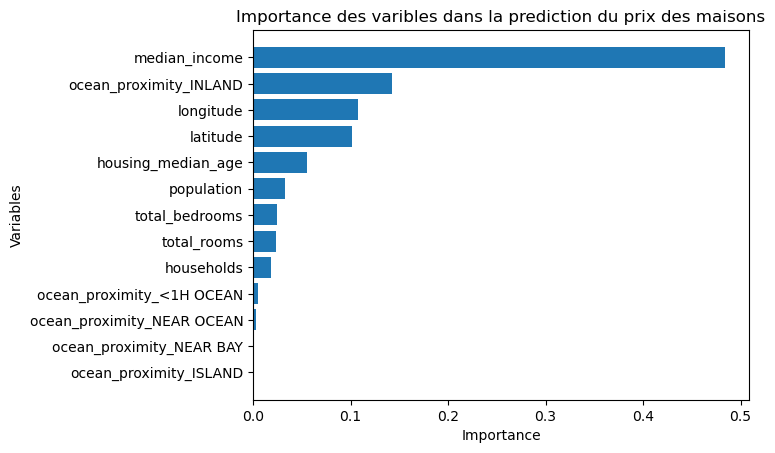

In [73]:
# Affichage de l'importance des variables 
importances = pd.Series(tree.feature_importances_, index=x_train.columns)
importances_sorted = importances.sort_values()
plt.barh(importances_sorted.index, importances_sorted)
plt.title('Importance des varibles dans la prediction du prix des maisons')
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.show()

le modele nous revele ce que l'on a deja vu sur le plan bivarié. Les variables les plus importantes dans ce modele reste le meme

On va maintenant s'interesser aux predictions sur la base test

In [76]:
from sklearn.metrics import mean_absolute_error, median_absolute_error, explained_variance_score, r2_score

# Prediction sur la base d'apprentissage et la base de test
y_train_pred = tree.predict(x_train)
y_test_pred = tree.predict(x_test)

# Calcul des métriques sur la base d'apprentissage et la base de test
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_medae = median_absolute_error(y_train, y_train_pred)
test_medae = median_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_evs = explained_variance_score(y_train, y_train_pred)
test_evs = explained_variance_score(y_test, y_test_pred)

# Affichage des resultats dans un tableau
results = pd.DataFrame({'Metrique': ['RMSE', 'MAE', 'MedAE', 'R2', 'EVS'],
                        'Apprentissage': [train_rmse, train_mae, train_medae, train_r2, train_evs],
                        'Test': [test_rmse, test_mae, test_medae, test_r2, test_evs]})
results.set_index('Metrique', inplace=True)
print(results)

          Apprentissage          Test
Metrique                             
RMSE                0.0  70713.309671
MAE                 0.0  44382.698159
MedAE               0.0  25300.000000
R2                  1.0      0.618411
EVS                 1.0      0.618453


Sur la base d'apprentissage, on a un R2 de 1, donc le modele que l'on vient de construire est parfait, un RMSE à 0, c'est à dire la difference entre la valeur predite et la valeur observée est completement nulle, en revanche sur la base de Test le R2 est de 0.61, cela veut tout simplement dire que le modele que l'on a obtenu sans optimisation overfit

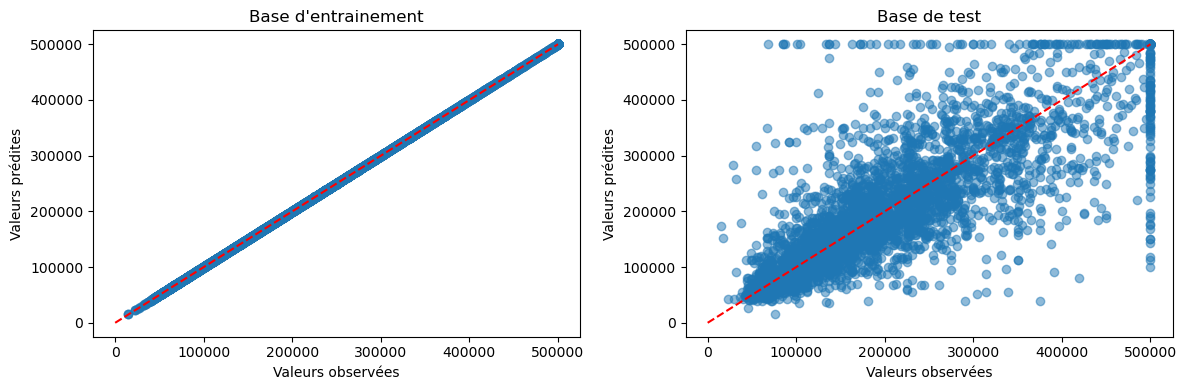

In [80]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Graphique pour la base d'entrainement
y_train_pred = tree.predict(x_train)
axs[0].scatter(y_train, y_train_pred, alpha=0.5)
axs[0].plot([0, np.max(y_train)], [0, np.max(y_train)], 'r--')
axs[0].set_xlabel('Valeurs observées')
axs[0].set_ylabel('Valeurs prédites')
axs[0].set_title('Base d\'entrainement')

# Graphique pour la base de test
y_test_pred = tree.predict(x_test)
axs[1].scatter(y_test, y_test_pred, alpha=0.5)
axs[1].plot([0, np.max(y_test)], [0, np.max(y_test)], 'r--')
axs[1].set_xlabel('Valeurs observées')
axs[1].set_ylabel('Valeurs prédites')
axs[1].set_title('Base de test')

# Affichage des graphiques
plt.tight_layout()
plt.show()

### 5.4 Arbre optimisé avec un élagage (pruning)

On va utiliser la validation croisée pour trouver la profondeur de l'arbre qui minimise la RMSE
Rappel : dans un arbre de regression, l'optimisation se fait sur la RMSE
Et en classification, l'optimisation se fait sur la precision

Profondeur optimale : 9


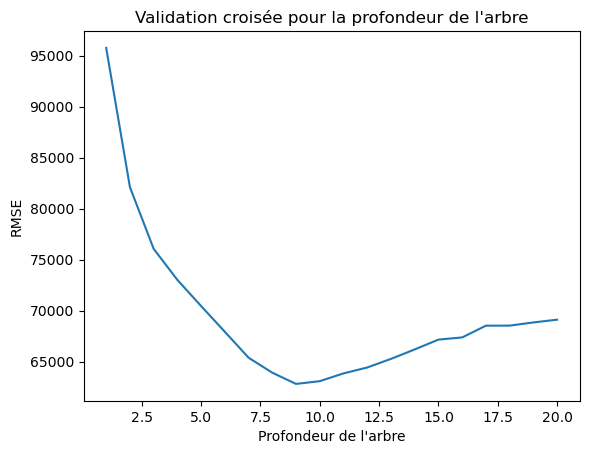

In [100]:
from sklearn.model_selection import GridSearchCV

# Definition de la grille de parametres 
param_grid = {'max_depth': np.arange(1, 21)}

# Instanciation de l'estimateur de l'arbre de décision 
tree = DecisionTreeRegressor(random_state=42)

# Instanciation de l'objet GridSearchCV (pour faire la validation croisée et trouver la performance optimale)
grid_tree = GridSearchCV(tree, param_grid, cv=5, scoring='neg_mean_squared_error')

# Entrainement de l'objet GridSearchCV
grid_tree.fit(x_train, y_train)

# Affichage de la profondeur optimale
print("Profondeur optimale :", grid_tree.best_params_['max_depth'])

# Affichage de la courbe de validation croisée pour la profondeur de l'arbre
plt.plot(param_grid['max_depth'], np.sqrt(-grid_tree.cv_results_['mean_test_score']))
plt.xlabel('Profondeur de l\'arbre')
plt.ylabel('RMSE')
plt.title('Validation croisée pour la profondeur de l\'arbre')
plt.show()

la profondeur qui minimise la rmse est de 9. On va réentrainer le model en utilisant comme parametre max_depth=9

In [101]:
# Entrainement d'un nouvel arbre avec la profondeur optimale
tree_optimal = DecisionTreeRegressor(max_depth=grid_tree.best_params_['max_depth'], random_state=42)
tree_optimal.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=np.int64(9), random_state=42)

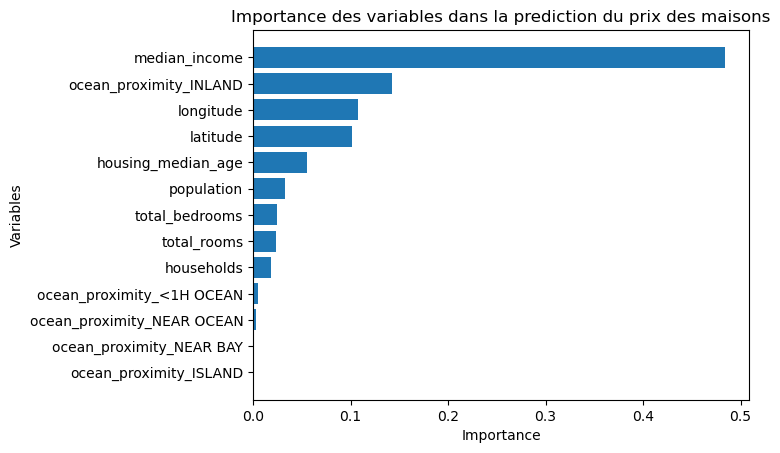

In [102]:
# Affichage de l'importance des variables 
importances = pd.Series(tree_optimal.feature_importances_, index=x_train.columns)
importance_sorted = importances.sort_values()
plt.barh(importances_sorted.index, importances_sorted)
plt.title('Importance des variables dans la prediction du prix des maisons')
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.show()

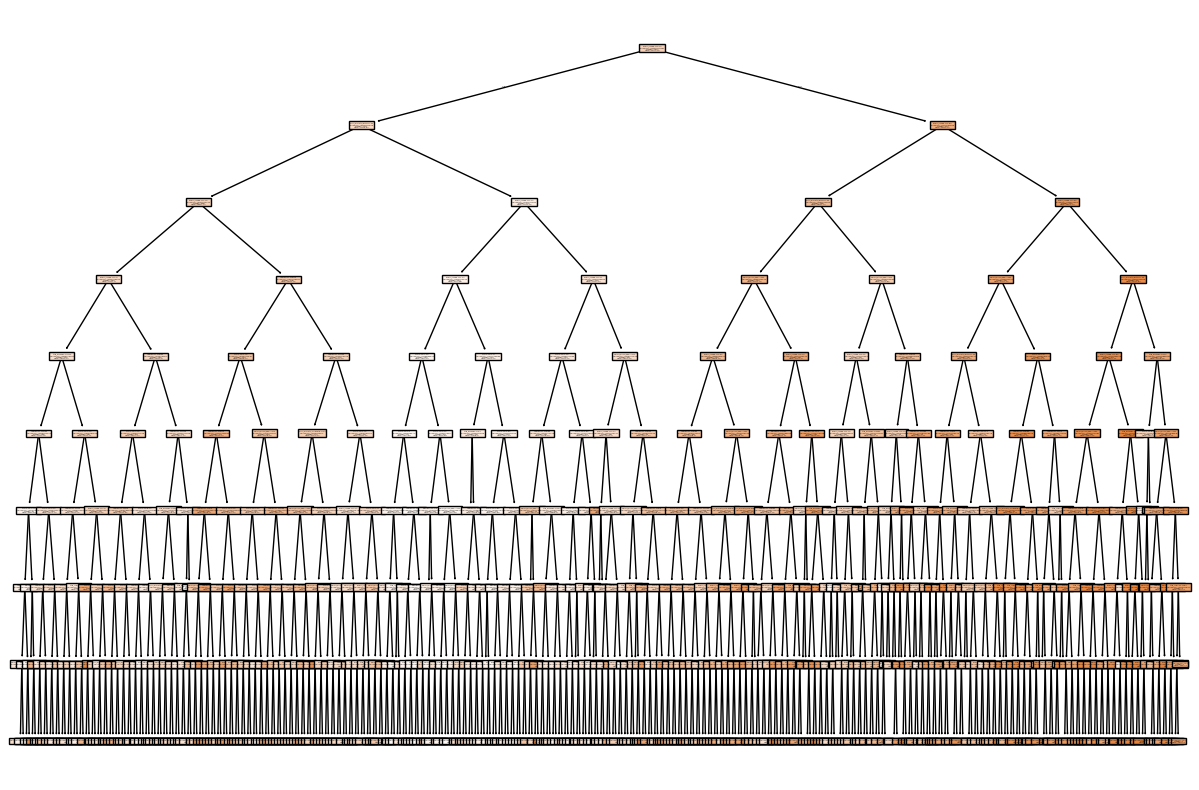

In [84]:
# Affichage de l'arbre
plt.figure(figsize=(15, 10))
plot_tree(tree_optimal, feature_names=x_train.columns, filled=True)
plt.show()

In [103]:
from sklearn.metrics import mean_absolute_error, median_absolute_error, explained_variance_score, r2_score

# Prediction sur la base d'apprentissage et la base de test
y_train_pred = tree_optimal.predict(x_train)
y_test_pred = tree_optimal.predict(x_test)

# Calcul des métriques sur la base d'apprentissage et la base de test
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_medae = median_absolute_error(y_train, y_train_pred)
test_medae = median_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_evs = explained_variance_score(y_train, y_train_pred)
test_evs = explained_variance_score(y_test, y_test_pred)

# Affichage des resultats dans un tableau
results = pd.DataFrame({'Metrique': ['RMSE', 'MAE', 'MedAE', 'R2', 'EVS'],
                        'Apprentissage': [train_rmse, train_mae, train_medae, train_r2, train_evs],
                        'Test': [test_rmse, test_mae, test_medae, test_r2, test_evs]})
results.set_index('Metrique', inplace=True)
print(results)

          Apprentissage          Test
Metrique                             
RMSE       52623.909413  64193.768674
MAE        36242.280327  41999.068763
MedAE      25005.760624  27808.855498
R2             0.792840      0.685530
EVS            0.792840      0.685584


sur la base d'apprentissage, on a un R2 qui est à 79% et sur la base de test à 68%, c'est deja mieux qu'avant. Il faut toujours s'assurer que les performances sur la base Test ne soit pas trop décalé de celle sur la base test.
Avec une meilleure selection des variables, on aurait pu avoir un arbre plus presentable (Il faut chercher comment on pourrait plus l'optimiser, on peut par exemple optimiser la selection des variables, on avait par exemple des vars tres corrélées, est ce qu'on enlevant certaines variales dans l'arbre de décision, est ce qu'on ameliorait les performances

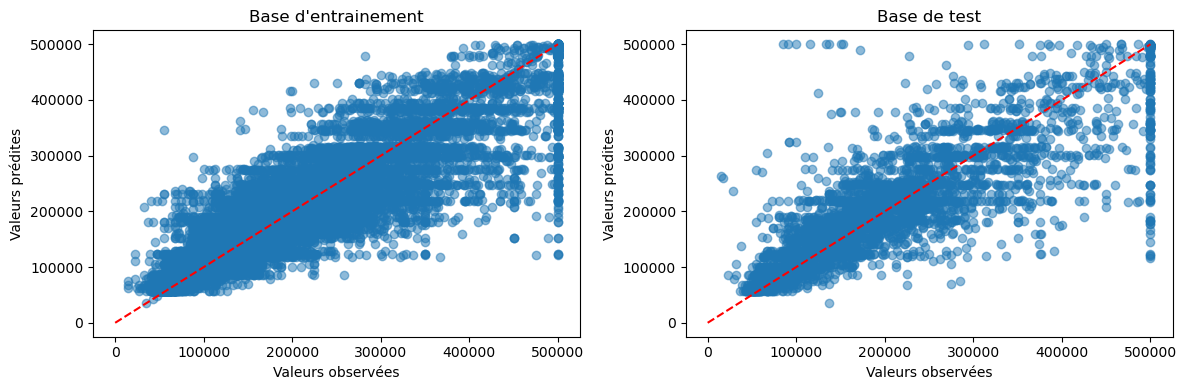

In [104]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Graphique pour la base d'entrainement
y_train_pred = tree_optimal.predict(x_train)
axs[0].scatter(y_train, y_train_pred, alpha=0.5)
axs[0].plot([0, np.max(y_train)], [0, np.max(y_train)], 'r--')
axs[0].set_xlabel('Valeurs observées')
axs[0].set_ylabel('Valeurs prédites')
axs[0].set_title('Base d\'entrainement')

# Graphique pour la base de test
y_test_pred = tree_optimal.predict(x_test)
axs[1].scatter(y_test, y_test_pred, alpha=0.5)
axs[1].plot([0, np.max(y_test)], [0, np.max(y_test)], 'r--')
axs[1].set_xlabel('Valeurs observées')
axs[1].set_ylabel('Valeurs prédites')
axs[1].set_title('Base de test')

# Affichage des graphiques
plt.tight_layout()
plt.show()

On va egalement tester un autre découpage de l'arbre

### 5.5 Tester une autre coupure de l'arbre

In [105]:
# Entrainement d'un nouvel arbre avec la profondeur optimale
tree_other = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_other.fit(x_train, y_train)
                                

DecisionTreeRegressor(max_depth=4, random_state=42)

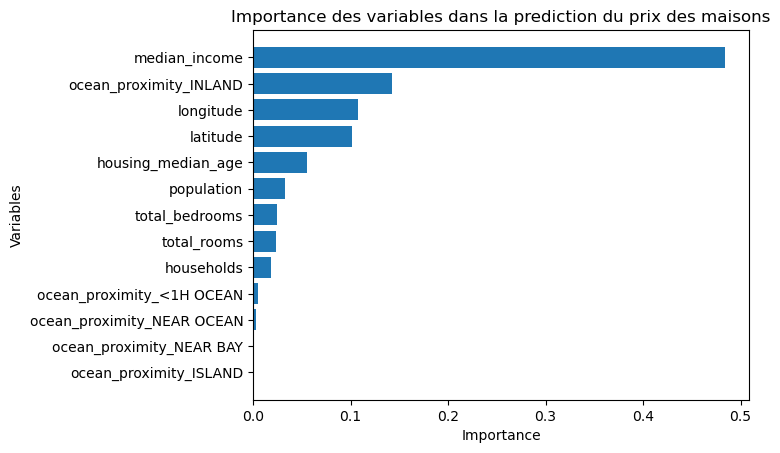

In [106]:
# Affichage de l'importance des variables 
importances = pd.Series(tree_other.feature_importances_, index=x_train.columns)
importance_sorted = importances.sort_values()
plt.barh(importances_sorted.index, importances_sorted)
plt.title('Importance des variables dans la prediction du prix des maisons')
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.show()

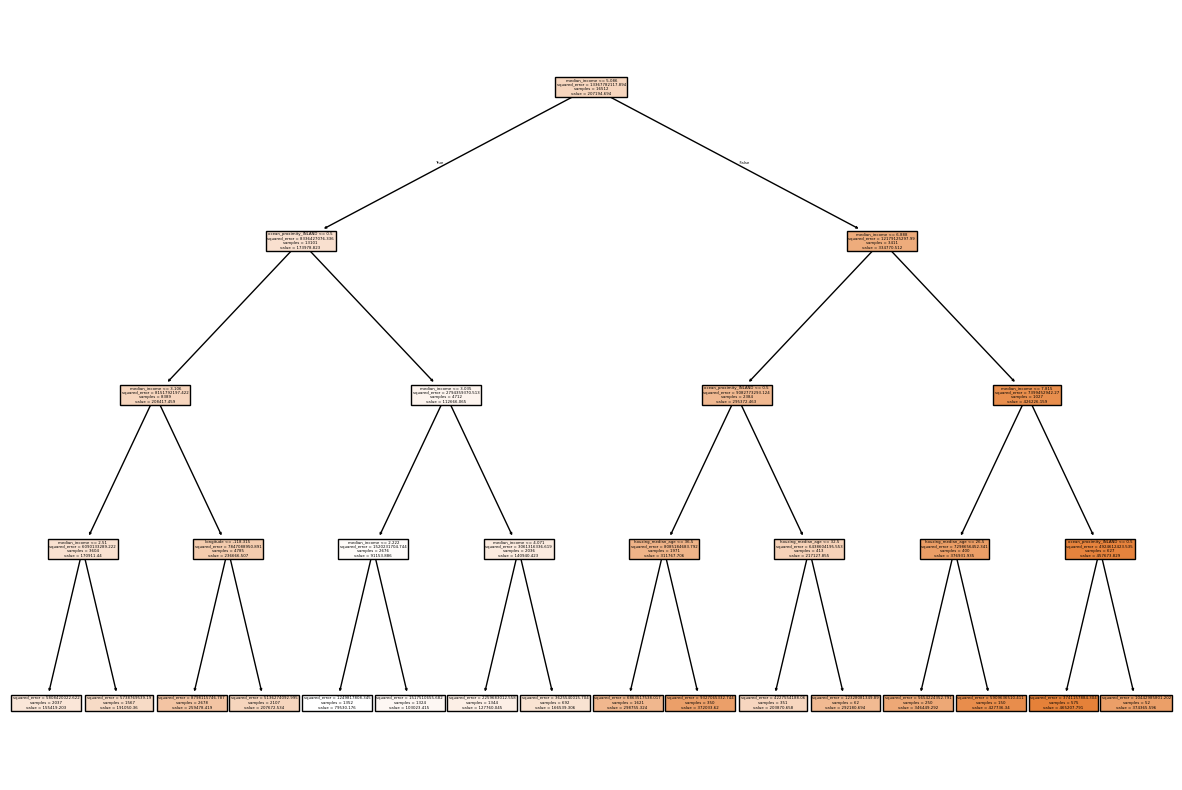

In [107]:
# Affichage de l'arbre
plt.figure(figsize=(15, 10))
plot_tree(tree_other, feature_names=x_train.columns, filled=True)
plt.show()

la encore, c'est toujours profond et j'arrive toujours pas à lire.

Regardons les performances avec ce découpage

In [108]:
from sklearn.metrics import mean_absolute_error, median_absolute_error, explained_variance_score, r2_score

# Prediction sur la base d'apprentissage et la base de test
y_train_pred = tree_other.predict(x_train)
y_test_pred = tree_other.predict(x_test)

# Calcul des métriques sur la base d'apprentissage et la base de test
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_medae = median_absolute_error(y_train, y_train_pred)
test_medae = median_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_evs = explained_variance_score(y_train, y_train_pred)
test_evs = explained_variance_score(y_test, y_test_pred)

# Affichage des resultats dans un tableau
results = pd.DataFrame({'Metrique': ['RMSE', 'MAE', 'MedAE', 'R2', 'EVS'],
                        'Apprentissage': [train_rmse, train_mae, train_medae, train_r2, train_evs],
                        'Test': [test_rmse, test_mae, test_medae, test_r2, test_evs]})
results.set_index('Metrique', inplace=True)
print(results)

          Apprentissage          Test
Metrique                             
RMSE       72204.591609  73811.562991
MAE        51994.909367  52474.097859
MedAE      36619.202749  36011.087006
R2             0.609995      0.584241
EVS            0.609995      0.584272


**On baisse quand meme les performance...**